# 📈 Model 04 — Logistic Regression

Baseline linear model trained on balanced SMOTE data.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



--- MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.98      0.92      0.95    113975
           1       0.20      0.57      0.29      4133

    accuracy                           0.90    118108
   macro avg       0.59      0.74      0.62    118108
weighted avg       0.96      0.90      0.93    118108

ROC-AUC: 0.8409
PR-AUC: 0.3405


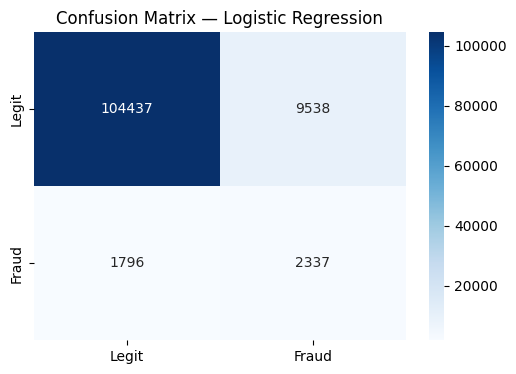

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

# Load data
train = pd.read_csv('../data/train_balanced.csv')
test = pd.read_csv('../data/test.csv')

X_train = train.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_train = train['isFraud']
X_test = test.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_test = test['isFraud']

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print("\n--- MODEL EVALUATION ---")
print(classification_report(y_test, preds))
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
precision, recall, _ = precision_recall_curve(y_test, probs)
print(f"PR-AUC: {auc(recall, precision):.4f}")

# Plot
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — Logistic Regression')
plt.show()